# ML Challenge - [Fraud Detection in Electricity and Gas Comsumption](https://zindi.africa/competitions/fraud-detection-in-electricity-and-gas-consumption-challenge/data)



In [1]:
# Import libs
# utility libs
import os
import sys
from pathlib import Path
# DS and ML libs
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## 1. Set up workdir

In [2]:
# set up work env
CURRENT_DIR = Path.cwd()
# please consider to change the value to find your root dir
ROOT_DIR = CURRENT_DIR.parents[0]
# data
DATA_DIR = os.path.join(ROOT_DIR, "data")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
# models output dir
MODELS_DIR = os.path.join(ROOT_DIR, "models")
# add root dir to sys path
sys.path.insert(0, str(ROOT_DIR))

In [3]:
# import custom palettes for data viz
import utils.dataviz_utils as custom_viz

[^v^] Seaborn configured with style: 'darkgrid', context: 'notebook'
[°-°] Matplotlib rcParams configured


In [4]:
# load files: invoice files are bigger, so we use the option low_memory to hide the pandas's warning
# train
client_train_df = pd.read_csv(os.path.join(TRAIN_DIR, "client_train.csv"))
invoice_train_df = pd.read_csv(os.path.join(TRAIN_DIR, "invoice_train.csv"), low_memory=False)
# test
client_test_df = pd.read_csv(os.path.join(TEST_DIR, "client_test.csv"))
invoice_test_df = pd.read_csv(os.path.join(TEST_DIR, "invoice_test.csv"), low_memory=False)

## 2. EDA

__2.1. Explore the data__

In [ ]:
# train data
print("="*100)
print(f"\n{'='*10} Client(Train) {client_train_df.shape} {'='*20}") # shape: (135493, 6)
print(client_train_df.head(3))

print(f"\n{'='*10} Invoice(Train) {invoice_train_df.shape} {'='*20}") # shape: (4476749, 16)
print(invoice_train_df.head(3))

print(f"\n{'='*10} Client(Test) {client_test_df.shape} {'='*20}") # shape: (58069, 5)
print(client_test_df.head(3))

print(f"\n{'='*10} Invoice(Test) {invoice_test_df.shape} {'='*20}") # shape: (1939730, 16)
print(invoice_test_df.head(3))


========== Client(Train) (135493, 6) ====================
   disrict        client_id  client_catg  region creation_date  target
0       60   train_Client_0           11     101    31/12/1994     0.0
1       69   train_Client_1           11     107    29/05/2002     0.0
2       62  train_Client_10           11     301    13/03/1986     0.0

========== Invoice(Train) (4476749, 16) ====================
        client_id invoice_date  ...  months_number  counter_type
0  train_Client_0   2014-03-24  ...              4          ELEC
1  train_Client_0   2013-03-29  ...              4          ELEC
2  train_Client_0   2015-03-23  ...              4          ELEC

[3 rows x 16 columns]

========== Client(Test) (58069, 5) ====================
   disrict       client_id  client_catg  region creation_date
0       62   test_Client_0           11     307    28/05/2002
1       69   test_Client_1           11     103    06/08/2009
2       62  test_Client_10           11     310    07/04/2004

======

In [ ]:
# info
# date format should be converted
client_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [ ]:
# date format should be converted to pd datetime
invoice_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [ ]:
# client_id has a col with the same name in invoice; can be used to merge both
print(f"Client unique: {client_train_df.client_id.nunique()}\nValues: {client_train_df.client_id.unique()}")

Client unique: 135493
Values: ['train_Client_0' 'train_Client_1' 'train_Client_10' ...
 'train_Client_99997' 'train_Client_99998' 'train_Client_99999']


In [ ]:
# display uniqu values in any cols
# - client catg(3): [11, 12, 51], 
# - disrict(4): [60 69 62 63]
# - target(2): [0.0, 1.0] can be changed as categ var
print(f"{'='*10} Client Train {'='*20}")
for col in client_train_df:
    print(f"{'='*5}\n{col}: N ({client_train_df[col].nunique()}) {'='*10}\n{client_train_df[col].unique()}\n")

========== Client Train ====================
=====
disrict: N (4) ==========
[60 69 62 63]

=====
client_id: N (135493) ==========
['train_Client_0' 'train_Client_1' 'train_Client_10' ...
 'train_Client_99997' 'train_Client_99998' 'train_Client_99999']

=====
client_catg: N (3) ==========
[11 12 51]

=====
region: N (25) ==========
[101 107 301 105 303 103 309 311 304 104 312 305 306 308 372 307 313 310
 371 302 106 379 399 206 199]

=====
creation_date: N (8088) ==========
['31/12/1994' '29/05/2002' '13/03/1986' ... '16/08/2004' '30/08/1978'
 '25/05/1978']

=====
target: N (2) ==========
[0. 1.]



In [ ]:
# counter status has mixed dtypes values: e.g. A, 0 etc.
# is reading_remarque relevant for the fraud detection?
# counter type(2): ["ELEC", "GAZ"] -> catg
print(f"{'='*10} Invoice Train {'='*20}")
for col in invoice_train_df:
    print(f"{'='*5}\n{col}: N ({invoice_train_df[col].nunique()}) {'='*10}\n{invoice_train_df[col].unique()}\n")

========== Invoice Train ====================
=====
client_id: N (135493) ==========
['train_Client_0' 'train_Client_1' 'train_Client_10' ...
 'train_Client_99997' 'train_Client_99998' 'train_Client_99999']

=====
invoice_date: N (8275) ==========
['2014-03-24' '2013-03-29' '2015-03-23' ... '1995-11-28' '1982-07-04'
 '1996-09-02']

=====
tarif_type: N (17) ==========
[11 40 15 10 12 14 13 45 29  9 30  8 21 42 27 18 24]

=====
counter_number: N (201893) ==========
[1335667  678902  572765 ... 4811719  262195  560948]

=====
counter_statue: N (12) ==========
['0' '1' '5' '4' '3' '2' '769' 'A' '618' '269375' '46' '420']

=====
counter_code: N (42) ==========
[203 207 413   5 467 202 420 410  10 483  25 433 407 204 214 442 453 506
 450 403 333 201 102 305 210 101 532  40 310 565 600 307 303 222  65   0
 227 325  16 317 367   1]

=====
reading_remarque: N (8) ==========
[  8   6   9   7 207 413 203   5]

=====
counter_coefficient: N (16) ==========
[ 1  3  0 10  4 33 50 20  2  6 40  9 30  5

In [ ]:
# the data set seems to do not have any missing values
client_train_df.isna().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [33]:
invoice_train_df.isna().sum()

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [ ]:
# duplicated?
invoice_train_df[invoice_train_df.duplicated()]

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
951893,train_Client_125864,2011-12-12,11,101545,5,413,6,1,0,0,0,0,13680,13680,2,ELEC
1755798,train_Client_25894,2010-07-13,40,6986740,5,5,6,1,0,0,0,0,0,0,2,GAZ
2137999,train_Client_3636,2012-01-18,40,312650,5,5,6,1,0,0,0,0,623,623,2,GAZ
2163374,train_Client_37069,2010-10-11,11,5284,5,413,6,1,0,0,0,0,99429,99429,2,ELEC
2433919,train_Client_44407,2008-02-28,11,66921,5,203,6,1,0,0,0,0,0,0,2,ELEC
2805729,train_Client_54609,2010-04-06,11,200912,5,207,6,1,0,0,0,0,0,0,2,ELEC
3260191,train_Client_66981,2006-07-17,11,132701,5,420,6,1,0,0,0,0,5946,5946,2,ELEC
3260198,train_Client_66981,2006-07-17,11,132701,5,420,6,1,0,0,0,0,5946,5946,2,ELEC
3394719,train_Client_7066,2014-10-28,40,4463323,5,5,6,1,0,0,0,0,80,80,2,GAZ
3462929,train_Client_72519,2013-01-21,11,246464,5,203,6,1,0,0,0,0,2954,2954,2,ELEC


In [ ]:
# no clear duplicated entries?!!!
invoice_train_df[invoice_train_df["client_id"] == "train_Client_125864"]

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
951847,train_Client_125864,2017-05-26,40,15139,0,5,9,1,788,0,0,0,6839,7627,4,GAZ
951848,train_Client_125864,2019-04-02,40,15139,0,5,8,1,931,0,0,0,7627,8558,20,GAZ
951849,train_Client_125864,2011-11-10,40,15139,0,5,6,1,311,0,0,0,570,881,8,GAZ
951850,train_Client_125864,2014-05-02,11,571507,0,413,8,1,400,120,0,0,16384,16904,2,ELEC
951851,train_Client_125864,2015-05-02,40,15139,0,5,9,1,599,0,0,0,3702,4301,4,GAZ
951852,train_Client_125864,2015-05-02,11,571507,0,413,8,1,800,400,579,0,22223,24002,4,ELEC
951853,train_Client_125864,2014-02-10,40,15139,0,5,6,1,220,0,0,0,3482,3702,4,GAZ
951854,train_Client_125864,2014-02-10,11,571507,0,413,9,1,800,400,800,2113,18110,22223,4,ELEC
951855,train_Client_125864,2008-06-10,40,15139,0,5,6,1,0,0,0,0,310,310,4,GAZ
951856,train_Client_125864,2006-09-19,40,15139,0,5,6,1,0,0,0,0,267,267,4,GAZ


In [ ]:
# numerical cols in client df
client_test_df.describe()

,disrict,client_catg,region
count,58069.000000,58069.000000,58069.000000
mean,63.510617,11.507224,206.018461
std,3.356708,4.395923,104.144028
min,60.000000,11.000000,101.000000
25%,62.000000,11.000000,103.000000
50%,62.000000,11.000000,107.000000
75%,69.000000,11.000000,307.000000
max,69.000000,51.000000,399.000000


In [69]:
# nums cols for invoce
invoice_train_df.describe()

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [ ]:
# number of not fraud : 127927
client_train_df[client_train_df["target"] == 0].count()

disrict          127927
client_id        127927
client_catg      127927
region           127927
creation_date    127927
target           127927
dtype: int64

In [ ]:
# make sense to have less fraudulent client
# 94,42% not fraud
# 5,58% fraud
client_fraud_distribution = client_train_df.groupby("target", as_index=False)["client_id"].agg({
    "fraudulent_client": ["count"]
})
client_fraud_distribution.columns = ["_".join(col).strip() for col in client_fraud_distribution.columns]
client_fraud_distribution

,target_,fraudulent_client_count
0,0.0,127927
1,1.0,7566


In [88]:
client_fraud_distribution.columns

Index(['target_', 'fraudulent_client_count'], dtype='object')

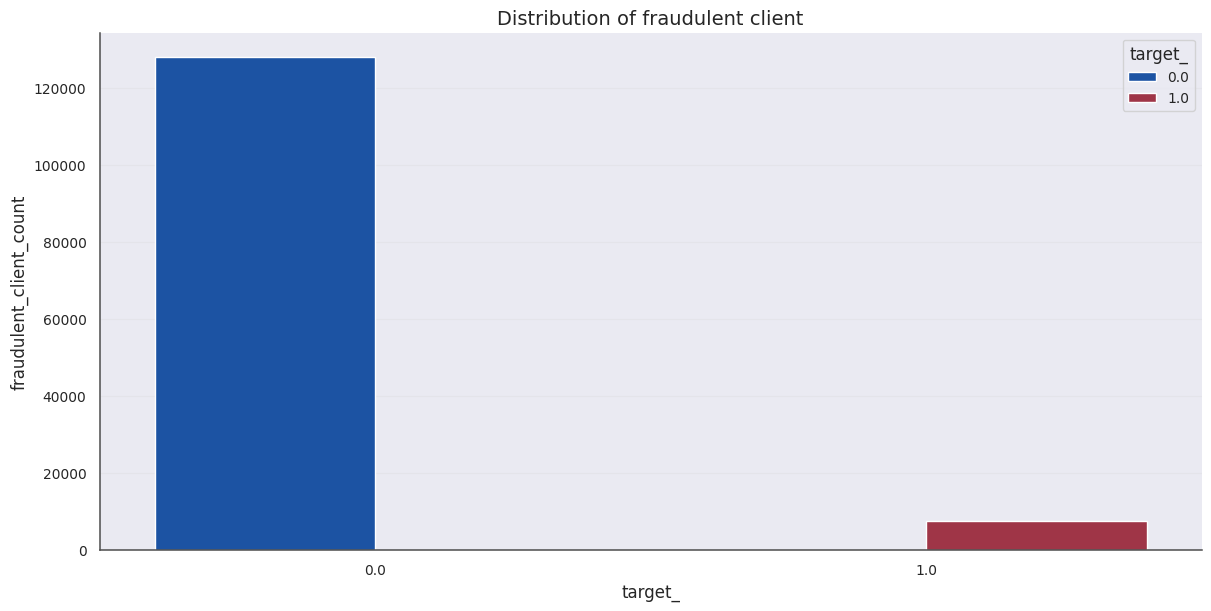

In [90]:
bar_ax = sns.barplot(
    data=client_fraud_distribution,
    x="target_",
    y="fraudulent_client_count",
    hue="target_",
    palette={
        0.0: custom_viz.PALETTE_BLUE[3],
        1.0: custom_viz.PALETTE_RED[3]
    }
)
plt.title("Distribution of fraudulent client")
plt.show()

__2.2 Preproprocess the data__

In [32]:
# help meths
# convert date to datetime
def convert_to_pd_datetime(dfs:list[pd.DataFrame], col_name:str) -> None:
    for df in dfs:
        df[col_name] = pd.to_datetime(df[col_name], yearfirst=True)

# convert to catg
def map_catg(df:pd.DataFrame, col_name:str, catg_dic: dict) -> None:
    df[col_name] = df[col_name].map(catg_dic).astype(np.int64)

# define a function to agg invoice by client id
def agg_invoice(invoice_df:pd.DataFrame, agg_feats: dict, agg_cond: str ="client_id"):
    agg_df = invoice_df.groupby(agg_cond).agg(agg_feats)
    # flatten the cols
    agg_df.columns = ["_".join(col).strip() for col in agg_df.columns]
    # reset the agg index
    agg_df.reset_index(inplace=True)
    return agg_df

def agg_invoice_add_counter_type(invoice_df:pd.DataFrame, agg_df: pd.DataFrame, agg_cond: str ="client_id"):
    tmp_invoice_copy_df = invoice_df.copy()
    tmp_invoice_copy_df["has_elec"] = (tmp_invoice_copy_df["counter_type"] == "ELEC").astype(int)
    tmp_invoice_copy_df["has_gaz"] = (tmp_invoice_copy_df["counter_type"] == "GAZ").astype(int)
    # agg
    agg_by_counter_type = tmp_invoice_copy_df.groupby(agg_cond).agg({
        "has_elec": ["sum", "mean"],
        "has_gaz": ["sum", "mean"],
        "counter_type": ["nunique"] # how many different types the client has
    })
    # agg_df = invoice_df.groupby(agg_cond).agg(agg_feats)
    # flatten the cols
    agg_by_counter_type.columns = ["_".join(col).strip() for col in agg_by_counter_type.columns]
    # reset the agg index
    agg_by_counter_type.reset_index(inplace=True)
    # merge with the existing agg df
    agg_df = agg_df.merge(agg_by_counter_type, on=agg_cond, how="left")
    return agg_df

# create a copy of df
def make_a_copy(df: pd.DataFrame):
    return df.copy()

In [33]:
# maping_dict
# - client catg(3): [11, 12, 51], 
# - disrict(4): [60 69 62 63]
target_map_dict = {0.0: 1, 1.0: 1}
counter_type_map_dict = {"ELEC": 0, "GAZ": 1}
client_catg_map_dict = {11: 0, 12: 1, 51: 2}
client_disrict_map_dict = {60: 0, 62: 1, 63: 2, 69: 3}
# take the agg content as a dict to automatate the process
invoice_agg_dict = {
    # "invoice_date": ["nunique", "min", "max", "count"],
    # "tarif_type": ["nunique"],
    # "counter_number": ["nunique"],
    # "counter_statue": ["nunique"],
    # "counter_code": ["nunique"],
    # "reading_remarque": ["nunique", "count"],
    # "counter_coefficient": ["nunique"],
    "consommation_level_1": ["count", "sum", "mean", "min", "max", "std"],
    "consommation_level_2": ["count", "sum", "mean", "min", "max", "std"],
    "consommation_level_3": ["count", "sum", "mean", "min", "max", "std"],
    "consommation_level_4": ["count", "sum", "mean", "min", "max", "std"],
    # "counter_type": ["first", "nunique"]
    # "old_index": ["nunique"],
    # "new_index": ["nunique"]
}
# invoice_train_df_agg = invoice_train_df.groupby("client_id").agg({
#     "invoice_date": ["nunique", "min", "max", "count"],
#     "tarif_type": ["nunique"],
#     "counter_number": ["nunique"],
#     "counter_statue": ["nunique"],
#     "counter_code": ["nunique"],
#     "reading_remarque": ["nunique", "count"],
#     "counter_coefficient": ["nunique"],
#     "consommation_level_1": ["nunique", "count", "sum", "mean", "std", "min", "max"],
#     "consommation_level_2": ["nunique", "count", "sum", "mean", "std", "min", "max"],
#     "consommation_level_3": ["nunique", "count", "sum", "mean", "std", "min", "max"],
#     "consommation_level_4": ["nunique", "count", "sum", "mean", "std", "min", "max"],
#     "old_index": ["nunique"],
#     "new_index": ["nunique"]
# })

In [36]:
# create a copy of all df
# train
client_train_df_00 = make_a_copy(client_train_df)
invoice_train_df_00 = make_a_copy(invoice_train_df)
# test
client_test_df_00 = make_a_copy(client_test_df)
invoice_test_df_00 = make_a_copy(invoice_test_df)


In [29]:
invoice_train_df_00.groupby("client_id").agg({
    "counter_type": ["first", "last"],
    "tarif_type": ["first", "last"],
    "counter_statue": ["first", "last"],
    "counter_code": ["first", "last"],
    "reading_remarque": ["first", "last"],
    "counter_coefficient": ["first", "last"],
}).head(10)

counter_type       tarif_type      counter_statue        
                           first  last      first last          first last   
client_id                                                                    
train_Client_0              ELEC  ELEC         11   11              0    0  \
train_Client_1              ELEC  ELEC         11   11              0    0   
train_Client_10             ELEC  ELEC         11   11              0    0   
train_Client_100            ELEC  ELEC         11   11              0    0   
train_Client_1000           ELEC  ELEC         11   11              0    0   
train_Client_10000           GAZ   GAZ         40   40              0    0   
train_Client_100000         ELEC  ELEC         11   11              1    0   
train_Client_100001          GAZ   GAZ         40   40              0    0   
train_Client_100002         ELEC  ELEC         11   11              0    0   
train_Client_100003         ELEC  ELEC         11   11              0    0   

                    counter_code      reading_remarque        
                           first last            first last   
client_id                                                     
train_Client_0               203  203                8    6  \
train_Client_1               203  203                8    8   
train_Client_10              203  203                8    6   
train_Client_100             413  413                6    6   
train_Client_1000            207  207                9    9   
train_Client_10000             5    5                9    6   
train_Client_100000          413  413                6    6   
train_Client_100001            5    5                8    6   
train_Client_100002          413  413                9    6   
train_Client_100003          467  467                9    9   

                    counter_coefficient       
                                  first last  
client_id                                     
train_Client_0                        1    1  
train_Client_1                        1    1  
train_Client_10                       1    1  
train_Client_100                      1    1  
train_Client_1000                     1    1  
train_Client_10000                    1    1  
train_Client_100000                   1    1  
train_Client_100001                   1    1  
train_Client_100002                   1    1  
train_Client_100003                   1    1

In [37]:
invoice_train_df_00.head(10)

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC
5,train_Client_0,2017-07-17,11,1335667,0,207,9,1,314,0,0,0,15638,15952,8,ELEC
6,train_Client_0,2018-12-07,11,1335667,0,207,9,1,541,0,0,0,15952,16493,12,ELEC
7,train_Client_0,2019-03-19,11,1335667,0,207,9,1,585,0,0,0,16493,17078,8,ELEC
8,train_Client_0,2011-07-22,11,1335667,0,203,9,1,1200,186,0,0,7770,9156,4,ELEC
9,train_Client_0,2011-11-22,11,1335667,0,203,6,1,1082,0,0,0,9156,10238,4,ELEC


In [38]:
# convert date for all data
convert_to_pd_datetime([client_train_df_00, client_test_df_00], "creation_date")
convert_to_pd_datetime([invoice_train_df_00, invoice_test_df_00], "invoice_date")

/tmp/ipykernel_66167/818184859.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col_name] = pd.to_datetime(df[col_name], yearfirst=True)
/tmp/ipykernel_66167/818184859.py:5: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col_name] = pd.to_datetime(df[col_name], yearfirst=True)


In [40]:
client_train_df_00.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   disrict        135493 non-null  int64         
 1   client_id      135493 non-null  object        
 2   client_catg    135493 non-null  int64         
 3   region         135493 non-null  int64         
 4   creation_date  135493 non-null  datetime64[ns]
 5   target         135493 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 6.2+ MB


In [41]:
# agg invoice
invoice_train_df_agg = agg_invoice(invoice_train_df_00, invoice_agg_dict)
invoice_train_df_agg = agg_invoice_add_counter_type(invoice_train_df_00, invoice_train_df_agg)

In [42]:
invoice_train_df_agg.head()

,client_id,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
0,train_Client_0,35,12334,352.400000,38,1200,310.343472,35,370,10.571429,...,0,0.000000,0,0,0.000000,35,1.0,0,0.0,1
1,train_Client_1,37,20629,557.540541,190,1207,197.935960,37,0,0.000000,...,0,0.000000,0,0,0.000000,37,1.0,0,0.0,1
2,train_Client_10,18,14375,798.611111,188,2400,513.841374,18,682,37.888889,...,0,0.000000,0,0,0.000000,18,1.0,0,0.0,1
3,train_Client_100,20,24,1.200000,0,15,3.607011,20,0,0.000000,...,0,0.000000,0,0,0.000000,20,1.0,0,0.0,1
4,train_Client_1000,14,9292,663.714286,124,800,224.831365,14,1468,104.857143,...,514,36.714286,0,382,105.421081,14,1.0,0,0.0,1


In [49]:
invoice_train_df_agg.columns[invoice_train_df_agg.isna().any()].tolist()

['consommation_level_1_std',
 'consommation_level_2_std',
 'consommation_level_3_std',
 'consommation_level_4_std']

In [54]:
invoice_train_df_agg.loc[:, invoice_train_df_agg.isna().any()]

,consommation_level_1_std,consommation_level_2_std,consommation_level_3_std,consommation_level_4_std
0,310.343472,43.568935,0.000000,0.000000
1,197.935960,0.000000,0.000000,0.000000
2,513.841374,160.748942,0.000000,0.000000
3,3.607011,0.000000,0.000000,0.000000
4,224.831365,167.155320,289.433294,105.421081
...,...,...,...,...
135488,16.496265,0.000000,0.000000,0.000000
135489,200.935258,4.841387,0.000000,0.000000
135490,211.123441,0.000000,0.000000,0.000000
135491,141.421356,91.216775,0.000000,0.000000


In [51]:
invoice_train_df_agg[invoice_train_df_agg["consommation_level_1_std"].isnull()]

,client_id,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
25,train_Client_100018,1,600,600.0,600,600,NaN,1,300,300.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
39,train_Client_100030,1,600,600.0,600,600,NaN,1,410,410.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
42,train_Client_100033,1,1600,1600.0,1600,1600,NaN,1,800,800.0,...,1820,1820.0,1820,1820,NaN,1,1.0,0,0.0,1
55,train_Client_100045,1,61,61.0,61,61,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
82,train_Client_10007,1,402,402.0,402,402,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135214,train_Client_99748,1,5,5.0,5,5,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135263,train_Client_99792,1,245,245.0,245,245,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135266,train_Client_99795,1,0,0.0,0,0,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
135365,train_Client_99884,1,689,689.0,689,689,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1


In [52]:
invoice_train_df_agg[invoice_train_df_agg["consommation_level_2_std"].isnull()]

,client_id,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,consommation_level_1_max,consommation_level_1_std,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
25,train_Client_100018,1,600,600.0,600,600,NaN,1,300,300.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
39,train_Client_100030,1,600,600.0,600,600,NaN,1,410,410.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
42,train_Client_100033,1,1600,1600.0,1600,1600,NaN,1,800,800.0,...,1820,1820.0,1820,1820,NaN,1,1.0,0,0.0,1
55,train_Client_100045,1,61,61.0,61,61,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
82,train_Client_10007,1,402,402.0,402,402,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135214,train_Client_99748,1,5,5.0,5,5,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135263,train_Client_99792,1,245,245.0,245,245,NaN,1,0,0.0,...,0,0.0,0,0,NaN,0,0.0,1,1.0,1
135266,train_Client_99795,1,0,0.0,0,0,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1
135365,train_Client_99884,1,689,689.0,689,689,NaN,1,0,0.0,...,0,0.0,0,0,NaN,1,1.0,0,0.0,1


In [55]:
# merge client and invoice
train_data_df = client_train_df_00.merge(invoice_train_df_agg, on="client_id", how="left")
train_data_df.head(3)

,disrict,client_id,client_catg,region,creation_date,target,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_min,...,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_min,consommation_level_4_max,consommation_level_4_std,has_elec_sum,has_elec_mean,has_gaz_sum,has_gaz_mean,counter_type_nunique
0,60,train_Client_0,11,101,1994-12-31,0.0,35,12334,352.400000,38,...,0,0.0,0,0,0.0,35,1.0,0,0.0,1
1,69,train_Client_1,11,107,2002-05-29,0.0,37,20629,557.540541,190,...,0,0.0,0,0,0.0,37,1.0,0,0.0,1
2,62,train_Client_10,11,301,1986-03-13,0.0,18,14375,798.611111,188,...,0,0.0,0,0,0.0,18,1.0,0,0.0,1


In [ ]:
# train_data_df.isna().any() fill na with 0 -> no invoice or no clear info the visualize

disrict                       False
client_id                     False
client_catg                   False
region                        False
creation_date                 False
target                        False
consommation_level_1_count    False
consommation_level_1_sum      False
consommation_level_1_mean     False
consommation_level_1_min      False
consommation_level_1_max      False
consommation_level_1_std       True
consommation_level_2_count    False
consommation_level_2_sum      False
consommation_level_2_mean     False
consommation_level_2_min      False
consommation_level_2_max      False
consommation_level_2_std       True
consommation_level_3_count    False
consommation_level_3_sum      False
consommation_level_3_mean     False
consommation_level_3_min      False
consommation_level_3_max      False
consommation_level_3_std       True
consommation_level_4_count    False
consommation_level_4_sum      False
consommation_level_4_mean     False
consommation_level_4_min    

In [ ]:
# # define a function to agg invoice by client id
# def agg_invoice(invoice_df, agg_feats, agg_cond="client_id"):
#     agg_df = invoice_df.groupby(agg_cond).agg(agg_feats)
#     # flatten the cols
#     agg_df.columns = ["_".join(col).strip() for col in agg_df.columns]
#     # reset the agg index
#     agg_df.reset_index(inplace=True)
#     return agg_df

In [ ]:
# invoice_train_df_agg.head()

invoice_date              ... old_index new_index
                           min         max  ...   nunique   nunique
client_id                                   ...                    
train_Client_0      2005-10-17  2019-03-19  ...        35        35
train_Client_1      2005-10-19  2019-04-02  ...        37        37
train_Client_10     2005-11-10  2019-05-02  ...        18        18
train_Client_100    2005-06-10  2012-09-25  ...         4         5
train_Client_1000   2015-02-13  2019-06-17  ...        14        14

[5 rows x 31 columns]

In [ ]:
# invoice_train_df_agg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 135493 entries, train_Client_0 to train_Client_99999
Data columns (total 31 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   invoice_date_min              135493 non-null  object 
 1   invoice_date_max              135493 non-null  object 
 2   invoice_date_count            135493 non-null  int64  
 3   tarif_type_nunique            135493 non-null  int64  
 4   counter_number_nunique        135493 non-null  int64  
 5   counter_statue_nunique        135493 non-null  int64  
 6   counter_code_nunique          135493 non-null  int64  
 7   reading_remarque_nunique      135493 non-null  int64  
 8   counter_coefficient_nunique   135493 non-null  int64  
 9   consommation_level_1_nunique  135493 non-null  int64  
 10  consommation_level_1_count    135493 non-null  int64  
 11  consommation_level_1_sum      135493 non-null  int64  
 12  consommation_level_1_mea

In [ ]:
# invoice_train_df_agg.columns

MultiIndex([(        'invoice_date',     'min'),
            (        'invoice_date',     'max'),
            (        'invoice_date',   'count'),
            (          'tarif_type', 'nunique'),
            (      'counter_number', 'nunique'),
            (      'counter_statue', 'nunique'),
            (        'counter_code', 'nunique'),
            (    'reading_remarque', 'nunique'),
            ( 'counter_coefficient', 'nunique'),
            ('consommation_level_1', 'nunique'),
            ('consommation_level_1',   'count'),
            ('consommation_level_1',     'sum'),
            ('consommation_level_1',    'mean'),
            ('consommation_level_1',     'std'),
            ('consommation_level_2', 'nunique'),
            ('consommation_level_2',   'count'),
            ('consommation_level_2',     'sum'),
            ('consommation_level_2',    'mean'),
            ('consommation_level_2',     'std'),
            ('consommation_level_3', 'nunique'),
            ('consom

In [ ]:
# ["_".join(col) for col in invoice_train_df_agg.columns]

['invoice_date_min',
 'invoice_date_max',
 'invoice_date_count',
 'tarif_type_nunique',
 'counter_number_nunique',
 'counter_statue_nunique',
 'counter_code_nunique',
 'reading_remarque_nunique',
 'counter_coefficient_nunique',
 'consommation_level_1_nunique',
 'consommation_level_1_count',
 'consommation_level_1_sum',
 'consommation_level_1_mean',
 'consommation_level_1_std',
 'consommation_level_2_nunique',
 'consommation_level_2_count',
 'consommation_level_2_sum',
 'consommation_level_2_mean',
 'consommation_level_2_std',
 'consommation_level_3_nunique',
 'consommation_level_3_count',
 'consommation_level_3_sum',
 'consommation_level_3_mean',
 'consommation_level_3_std',
 'consommation_level_4_nunique',
 'consommation_level_4_count',
 'consommation_level_4_sum',
 'consommation_level_4_mean',
 'consommation_level_4_std',
 'old_index_nunique',
 'new_index_nunique']

In [ ]:
# invoice_train_df_agg.columns = ["_".join(col) for col in invoice_train_df_agg.columns]
# invoice_train_df_agg.head(3)

,invoice_date_min,invoice_date_max,invoice_date_count,tarif_type_nunique,counter_number_nunique,counter_statue_nunique,counter_code_nunique,reading_remarque_nunique,counter_coefficient_nunique,consommation_level_1_nunique,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_std,consommation_level_2_nunique,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_std,consommation_level_3_nunique,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_std,consommation_level_4_nunique,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_std,old_index_nunique,new_index_nunique
client_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
train_Client_0,2005-10-17,2019-03-19,35,1,1,1,2,3,1,32,35,12334,352.400000,310.343472,3,35,370,10.571429,43.568935,1,35,0,0.0,0.0,1,35,0,0.0,0.0,35,35
train_Client_1,2005-10-19,2019-04-02,37,1,1,1,1,3,1,36,37,20629,557.540541,197.935960,1,37,0,0.000000,0.000000,1,37,0,0.0,0.0,1,37,0,0.0,0.0,37,37
train_Client_10,2005-11-10,2019-05-02,18,1,1,1,2,3,1,18,18,14375,798.611111,513.841374,2,18,682,37.888889,160.748942,1,18,0,0.0,0.0,1,18,0,0.0,0.0,18,18


In [ ]:
# # create a copy of df
# def make_a_copy(df):
#     return df.copy()

In [9]:
# make a copy of original df
client_train_df_00 = make_a_copy(client_train_df)
invoice_train_df_00 = make_a_copy(invoice_train_df)
client_test_df_00 = make_a_copy(client_test_df)
invoice_test_df_00 = make_a_copy(invoice_test_df)

In [41]:
# convert the date
client_train_df_00["creation_date"] = pd.to_datetime(client_train_df_00["creation_date"], yearfirst=True)
invoice_train_df_00["invoice_date"] = pd.to_datetime(invoice_train_df_00["invoice_date"], yearfirst=True)
client_test_df_00["creation_date"] = pd.to_datetime(client_test_df_00["creation_date"], yearfirst=True)
invoice_test_df_00["invoice_date"] = pd.to_datetime(invoice_test_df_00["invoice_date"], yearfirst=True)

In [42]:
client_train_df_00.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   disrict        135493 non-null  int64         
 1   client_id      135493 non-null  object        
 2   client_catg    135493 non-null  int64         
 3   region         135493 non-null  int64         
 4   creation_date  135493 non-null  datetime64[ns]
 5   target         135493 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 6.2+ MB


In [50]:
# client_train_df_00["creation_date"].dt.day
invoice_train_df_agg = agg_invoice(invoice_train_df_00, agg_feats=invoice_agg_dict)

In [51]:
invoice_train_df_agg.head()

,client_id,invoice_date_nunique,invoice_date_min,invoice_date_max,invoice_date_count,tarif_type_nunique,counter_number_nunique,counter_statue_nunique,counter_code_nunique,reading_remarque_nunique,reading_remarque_count,counter_coefficient_nunique,consommation_level_1_nunique,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_std,consommation_level_1_min,consommation_level_1_max,consommation_level_2_nunique,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_std,consommation_level_2_min,consommation_level_2_max,consommation_level_3_nunique,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_std,consommation_level_3_min,consommation_level_3_max,consommation_level_4_nunique,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_std,consommation_level_4_min,consommation_level_4_max,old_index_nunique,new_index_nunique
0,train_Client_0,35,2005-10-17,2019-03-19,35,1,1,1,2,3,35,1,32,35,12334,352.400000,310.343472,38,1200,3,35,370,10.571429,43.568935,0,186,1,35,0,0.000000,0.000000,0,0,1,35,0,0.000000,0.000000,0,0,35,35
1,train_Client_1,37,2005-10-19,2019-04-02,37,1,1,1,1,3,37,1,36,37,20629,557.540541,197.935960,190,1207,1,37,0,0.000000,0.000000,0,0,1,37,0,0.000000,0.000000,0,0,1,37,0,0.000000,0.000000,0,0,37,37
2,train_Client_10,18,2005-11-10,2019-05-02,18,1,1,1,2,3,18,1,18,18,14375,798.611111,513.841374,188,2400,2,18,682,37.888889,160.748942,0,682,1,18,0,0.000000,0.000000,0,0,1,18,0,0.000000,0.000000,0,0,18,18
3,train_Client_100,20,2005-06-10,2012-09-25,20,1,1,1,1,2,20,1,4,20,24,1.200000,3.607011,0,15,1,20,0,0.000000,0.000000,0,0,1,20,0,0.000000,0.000000,0,0,1,20,0,0.000000,0.000000,0,0,4,5
4,train_Client_1000,14,2015-02-13,2019-06-17,14,1,1,1,1,2,14,1,10,14,9292,663.714286,224.831365,124,800,4,14,1468,104.857143,167.155320,0,400,3,14,1643,117.357143,289.433294,0,800,3,14,514,36.714286,105.421081,0,382,14,14


In [53]:
client_test_df_00.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58069 entries, 0 to 58068
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   disrict        58069 non-null  int64         
 1   client_id      58069 non-null  object        
 2   client_catg    58069 non-null  int64         
 3   region         58069 non-null  int64         
 4   creation_date  58069 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 2.2+ MB


In [57]:
# merge client and invoice train to get the train data
train_data_df = client_train_df_00.merge(invoice_train_df_agg, on="client_id", how="left")

In [ ]:
# there are missing data when calculating the std for consum_lvl
# no invoice for client?
train_data_df.isna().sum()

disrict                            0
client_id                          0
client_catg                        0
region                             0
creation_date                      0
target                             0
invoice_date_nunique               0
invoice_date_min                   0
invoice_date_max                   0
invoice_date_count                 0
tarif_type_nunique                 0
counter_number_nunique             0
counter_statue_nunique             0
counter_code_nunique               0
reading_remarque_nunique           0
reading_remarque_count             0
counter_coefficient_nunique        0
consommation_level_1_nunique       0
consommation_level_1_count         0
consommation_level_1_sum           0
consommation_level_1_mean          0
consommation_level_1_std        4212
consommation_level_1_min           0
consommation_level_1_max           0
consommation_level_2_nunique       0
consommation_level_2_count         0
consommation_level_2_sum           0
c

In [64]:
train_data_df_00 = make_a_copy(train_data_df)

In [65]:
train_data_df_00.fillna(0, inplace=True)

In [66]:
train_data_df_00.isna().sum()

disrict                         0
client_id                       0
client_catg                     0
region                          0
creation_date                   0
target                          0
invoice_date_nunique            0
invoice_date_min                0
invoice_date_max                0
invoice_date_count              0
tarif_type_nunique              0
counter_number_nunique          0
counter_statue_nunique          0
counter_code_nunique            0
reading_remarque_nunique        0
reading_remarque_count          0
counter_coefficient_nunique     0
consommation_level_1_nunique    0
consommation_level_1_count      0
consommation_level_1_sum        0
consommation_level_1_mean       0
consommation_level_1_std        0
consommation_level_1_min        0
consommation_level_1_max        0
consommation_level_2_nunique    0
consommation_level_2_count      0
consommation_level_2_sum        0
consommation_level_2_mean       0
consommation_level_2_std        0
consommation_l

In [67]:
train_data_df_00.head()

,disrict,client_id,client_catg,region,creation_date,target,invoice_date_nunique,invoice_date_min,invoice_date_max,invoice_date_count,tarif_type_nunique,counter_number_nunique,counter_statue_nunique,counter_code_nunique,reading_remarque_nunique,reading_remarque_count,counter_coefficient_nunique,consommation_level_1_nunique,consommation_level_1_count,consommation_level_1_sum,consommation_level_1_mean,consommation_level_1_std,consommation_level_1_min,consommation_level_1_max,consommation_level_2_nunique,consommation_level_2_count,consommation_level_2_sum,consommation_level_2_mean,consommation_level_2_std,consommation_level_2_min,consommation_level_2_max,consommation_level_3_nunique,consommation_level_3_count,consommation_level_3_sum,consommation_level_3_mean,consommation_level_3_std,consommation_level_3_min,consommation_level_3_max,consommation_level_4_nunique,consommation_level_4_count,consommation_level_4_sum,consommation_level_4_mean,consommation_level_4_std,consommation_level_4_min,consommation_level_4_max,old_index_nunique,new_index_nunique
0,60,train_Client_0,11,101,1994-12-31,0.0,35,2005-10-17,2019-03-19,35,1,1,1,2,3,35,1,32,35,12334,352.400000,310.343472,38,1200,3,35,370,10.571429,43.568935,0,186,1,35,0,0.000000,0.000000,0,0,1,35,0,0.000000,0.000000,0,0,35,35
1,69,train_Client_1,11,107,2002-05-29,0.0,37,2005-10-19,2019-04-02,37,1,1,1,1,3,37,1,36,37,20629,557.540541,197.935960,190,1207,1,37,0,0.000000,0.000000,0,0,1,37,0,0.000000,0.000000,0,0,1,37,0,0.000000,0.000000,0,0,37,37
2,62,train_Client_10,11,301,1986-03-13,0.0,18,2005-11-10,2019-05-02,18,1,1,1,2,3,18,1,18,18,14375,798.611111,513.841374,188,2400,2,18,682,37.888889,160.748942,0,682,1,18,0,0.000000,0.000000,0,0,1,18,0,0.000000,0.000000,0,0,18,18
3,69,train_Client_100,11,105,1996-07-11,0.0,20,2005-06-10,2012-09-25,20,1,1,1,1,2,20,1,4,20,24,1.200000,3.607011,0,15,1,20,0,0.000000,0.000000,0,0,1,20,0,0.000000,0.000000,0,0,1,20,0,0.000000,0.000000,0,0,4,5
4,62,train_Client_1000,11,303,2014-10-14,0.0,14,2015-02-13,2019-06-17,14,1,1,1,1,2,14,1,10,14,9292,663.714286,224.831365,124,800,4,14,1468,104.857143,167.155320,0,400,3,14,1643,117.357143,289.433294,0,800,3,14,514,36.714286,105.421081,0,382,14,14
